In [1]:
%load_ext autoreload
%autoreload 2

In [39]:
config = \
{
            "save_path": 'wangguoqiang/shihua250807_mol5/skip_roundback_beam_test' ,
            "bascic_mol": "CB_Planner/data/basic_mol.json",
            "chembart_path":'/home/zhangyijian/ChemBart/v2/ChemBart_model/ChemBart_FULL_4.pth',
            "rl_path":'/home/zhangyijian/ChemBart/CB_Planner/CB_Planner/functions/ChemBart/model/CB_MCTS.pth',
            "ty_path":'/home/zhangyijian/ChemBart/CB_Planner/CB_Planner/functions/ChemBart/model/temp_yield_bart.pth', 
            # params for supervision
            "getdata": {
                "train": False,  # retain search data for RL training or not
                "max_train_data_num": 5000,  # if retain training data, at most how many data should be retained.
            },

            # params for computing
            "mcts": {
                #"mcts_times": 50, # iteration time per step
                "mcts_times": 20,
                "max_route_len": 8, # the max length of the route designed, if the program exceeds the limit but still haven't finished, return failed.
                "max_search_depth": 8, # the max depth of DFS in MCTS
                "temp_coef" : 1.0, # the temperature coefficient of policy 
                "Cpuct" : 10.0, # the Cpuct coeeficient in mcts
                "update_method" : 'avg', # or 'min'
                "debug": False, # print informantion when MCTS
            },

            "nn":{
                "gen_dev": "cuda:2", # device to load generation model (pre-trained model)
                "agt_dev": "cuda:2", # device to load agent model (pre-trained model)
                "pro_dev": "cuda:2", # device to load product (round trip) model (pre-trained model)
                "rl_dev": "cuda:2", # device to load RL model (fine-tuned model)
                "temp_yield_dev": "cuda:2", # device to load model for temperature and yield prediction (fine-tuned model)
                #"choiceperstep": 50, # num of choices generated in each node in the tree.
                "sampling_method": 'beam', #'top_k' / 'top_p' / 'beam'
                "topk": 10,
                "topp": 0.9,
                "num_samples": 10,
                #"temperature":1.0
            },

            # params for computing resources. If the cuda returns error or the gpu just does not work, reduce this params!
            "parallel":{
                "process_parallel": False,
                "pool_size": 3, # num of molecules (processes) that can be solved at the same time. Each process requires one cpu (so do not exceed num of cpus) and part of the gpu memory (so usually this param is much smaller than num of cpus).
                "semaphore_per_model": 3, # num of processes that can call a model at the same time, linited by the gpu memory.
            }
}




In [27]:
tasklist_1 = [
            ('Clc(cc1)cc2c1oc3c2c(Br)ccc3', 5),                    
            #('Oc1cccc(Br)c1-c1cc(Cl)ccc1Cl', 10),
            #('COc1cccc(Br)c1-c1cc(Cl)ccc1Cl', 10),
            ]


In [35]:
from CB_Planner.board import CB_Planner
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print('program strated~')
print('total data',len(tasklist_1))
planner = CB_Planner(config)    



program strated~
total data 1
成功创建保存目录：wangguoqiang/shihua250807_mol5/skip_roundback_beam_test/


In [36]:
ans = planner.plan(tasklist_1)


[DFS] Depth=3 | Node: COc1cccc(N)c1-c1cc(Cl)ccc1Cl | Total visits: 1
      Idx Precursors                     P      N    Q      U      PUCT  
      ------------------------------------------------------------
      0   COc1cccc([N+](=O)[O-])c1-c1cc(Cl)ccc1Cl 0.100  0    0.000  1.000  1.000 
      1   COc1cccc([N+](=O)[O-])c1Br.OB(O)c1cc(Cl)ccc1Cl 0.100  0    0.000  1.000  1.000 
      2   COc1cccc(N)c1B(O)O.Clc1ccc(Cl)c(Br)c1 0.100  0    0.000  1.000  1.000 
      3   COc1cccc(N)c1B(O)O.Clc1ccc(Cl)c(I)c1 0.100  0    0.000  1.000  1.000 
      4   (cycle) Nc1cccc(O)c1-c1cc(Cl)ccc1Cl.O=C([O-])[O-] 0.100  0    0.000  -      -     
      5   COc1cccc(N)c1Br.OB(O)c1cc(Cl)ccc1Cl 0.100  0    0.000  1.000  1.000 
      6   COc1cccc(NC(C)=O)c1-c1cc(Cl)ccc1Cl 0.100  0    0.000  1.000  1.000 
      7   COc1cccc([N+](=O)[O-])c1B(O)O.Clc1ccc(Cl)c(Br)c1 0.100  0    0.000  1.000  1.000 
      8   (cycle) Nc1cccc(O)c1-c1cc(Cl)ccc1Cl.O=C([O-])O 0.100  0    0.000  -      -     
      9   COc1cccc([N+]

In [37]:
ans

{'answer_0_Clc1ccc2oc3cccc(Br)c3c2c1_route_0': [{'success': 1,
   'probability': 0.9999999500000025},
  {'Clc1ccc2oc3cccc(Br)c3c2c1': {'BrBr': 'basic_molecule',
    'Clc1ccc2oc3ccccc3c2c1': 'basic_molecule'}},
  {'Clc1ccc2oc3cccc(Br)c3c2c1': {'reagents': 'CC(=O)[O-].[Na+].CC(=O)O',
    'precursors': 'BrBr.Clc1ccc2oc3ccccc3c2c1',
    'probability': 1.0,
    'temperature': 56.2977180480957,
    'yield': 78.48728942871094}}],
 'answer_0_Clc1ccc2oc3cccc(Br)c3c2c1_route_1': [{'success': 1,
   'probability': 0.9999997900000297},
  {'Clc1ccc2oc3cccc(Br)c3c2c1': {'Brc1cccc2oc3ccccc3c12': 'basic_molecule',
    'O=S(=O)(Cl)Cl': 'basic_molecule'}},
  {'Clc1ccc2oc3cccc(Br)c3c2c1': {'reagents': 'ClC(Cl)Cl',
    'precursors': 'Brc1cccc2oc3ccccc3c12.O=S(=O)(Cl)Cl',
    'probability': 1.0,
    'temperature': 46.56761169433594,
    'yield': 80.06831359863281}}],
 'answer_0_Clc1ccc2oc3cccc(Br)c3c2c1_route_2': [{'success': 1,
   'probability': 0.4472135820835507},
  {'Clc1ccc2oc3cccc(Br)c3c2c1': {'O=C(c1

In [38]:
planner.save_to_file(ans)

## read result

In [ ]:
from CB_Planner.functions.utils import Visualizer
from CB_Planner.functions.utils import RetroAnalyzer
from pathlib import Path

input_dir = '20250718_benchmark_topp_strict'
output_csv = 'result_file/20250718_benchmark_topp_strict.csv'
analyzer = RetroAnalyzer(input_dir, output_csv)
df_analysis = analyzer.analyze_directory()
reaction_view = Visualizer()

In [ ]:
#path = Path('250715_benchmark_beam_strict/answer_0_CC(=O)N1CCC(Nc2ccc3c(c2)C(=O)N(C[C@H](O)CN2CCc4ccccc4C2)CC3)CC1_route_1')
path = Path('path/to/result/file')
file_result = analyzer.analyze_file(path)

# 获取路径和反应条件
path = analyzer._get_route_path(file_result.reaction_data)
reagent_list, temp_list, yield_list = analyzer._get_reagent_path(file_result.reaction_data)

# 1️⃣ visualize route
reaction_view.visualize_route_only_mols(path)

# 2️⃣ visualize reaction conditions
reaction_view.visualize_reaction_conditions(reagent_list, temp_list, yield_list)

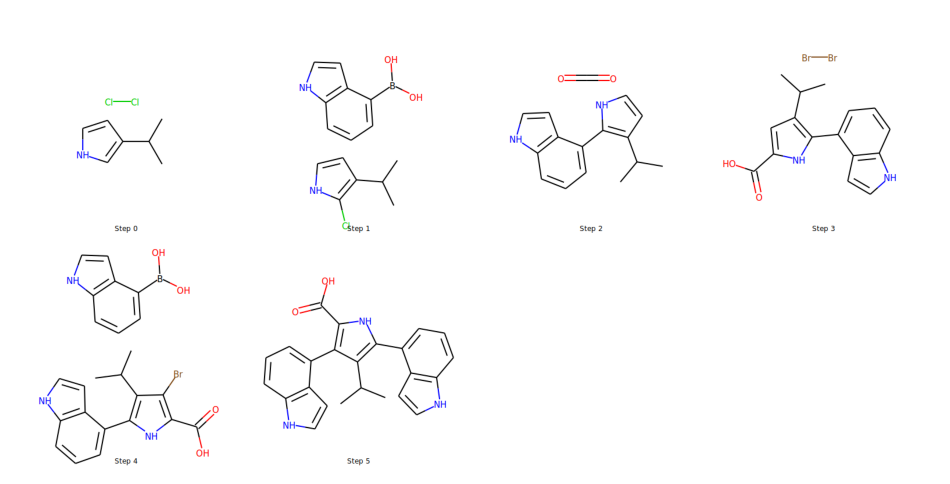

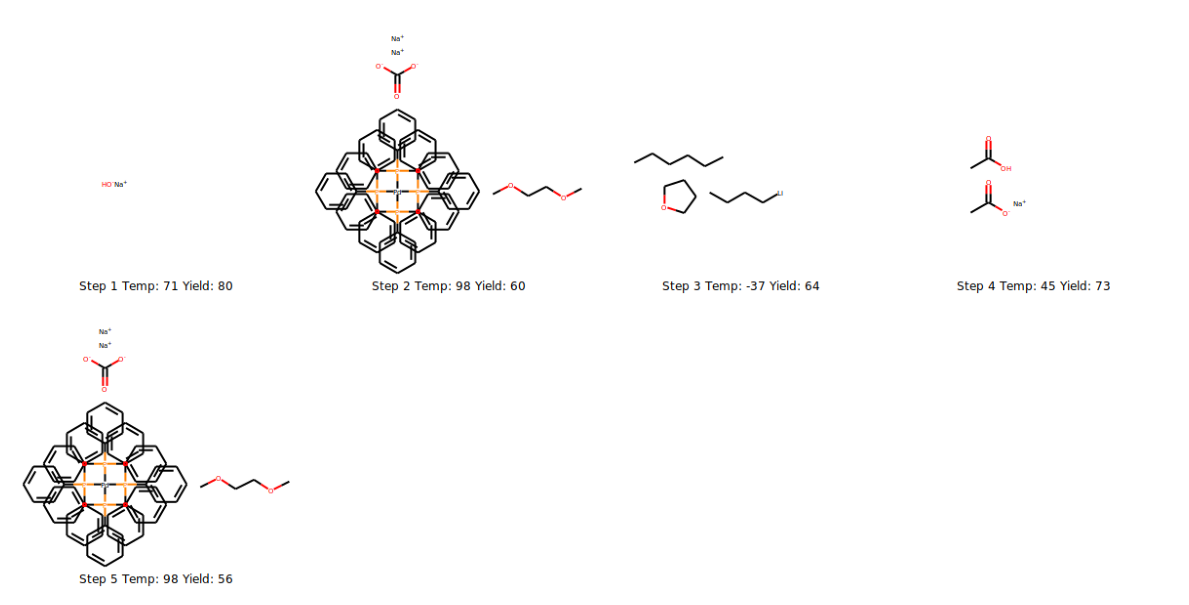

In [ ]:
#path = Path('/home/zhangyijian/ChemBart/CB_Planner/JMC/20250718_benchmark_beam_strict/answer_0_CC(C)c1c(-c2cccc3[nH]ccc23)[nH]c(C(=O)O)c1-c1cccc2[nH]ccc12_route_0')

path = Path('path/to/result/file')
file_result = analyzer.analyze_file(path)

# 获取路径和反应条件
path = analyzer._get_route_path(file_result.reaction_data)
reagent_list, temp_list, yield_list = analyzer._get_reagent_path(file_result.reaction_data)

# 1️⃣ visualize route
reaction_view.visualize_route_only_mols(path)

# 2️⃣ visualize reaction conditions
reaction_view.visualize_reaction_conditions(reagent_list, temp_list, yield_list)